In [32]:
import pandas as pd
import vectorbt as vbt
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals
from ggTrader.Utils import *


In [33]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    # "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    # "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    # "TON",  # 20 Toncoin
    # "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    # "MNT",  # 23 Mantle
    # "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Walk Forward Optimization

In [34]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
# symbols = ["BTC", "ETH", "LTC"]
symbols = top_kraken[:5]
interval = "4h"
n_trials = 50
# sampler = RandomSampler(seed=42)  # optional seed for reproducibility
sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.02,
                  'sar_maximum': 0.2,
                  'atr_multiplier': 3,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,  # atr multiplier for chandelier exit
                  'use_high': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)
close = data_df.xs('close', axis=1, level=1)
print(close.info())
print(close.columns)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6019 entries, 2023-01-01 00:00:00+00:00 to 2025-09-30 00:00:00+00:00
Freq: 4h
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BTC     6019 non-null   float32
 1   ETH     6019 non-null   float32
 2   XRP     6019 non-null   float32
 3   SOL     6019 non-null   float32
 4   TRX     6019 non-null   float32
dtypes: float32(5)
memory usage: 164.6 KB
None
Index(['BTC', 'ETH', 'XRP', 'SOL', 'TRX'], dtype='object', name='symbol')


Computed test_size=1205, max_train_size=2403


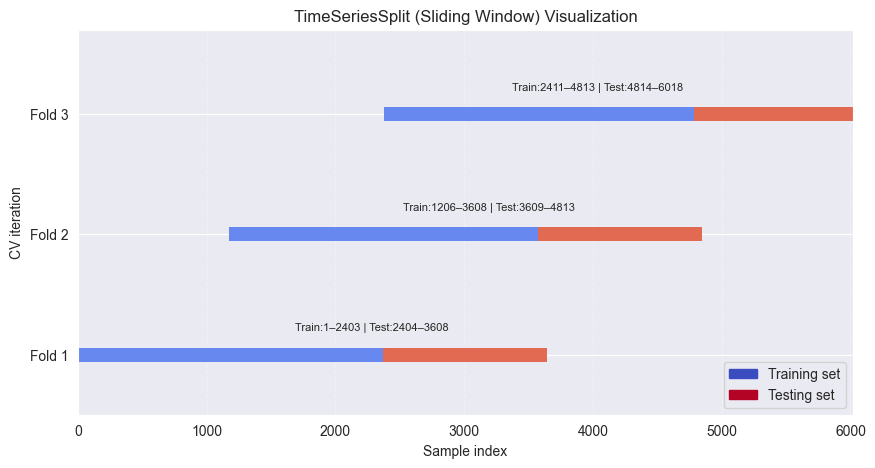

   Fold               Start                 End          Start Test  \
0     1 2023-01-01 04:00:00 2024-02-05 12:00:00 2024-02-05 16:00:00   
1     2 2023-07-21 00:00:00 2024-08-24 08:00:00 2024-08-24 12:00:00   
2     3 2024-02-06 20:00:00 2025-03-13 04:00:00 2025-03-13 08:00:00   

             End Test      Train Period       Test Period  
0 2024-08-24 08:00:00 400 days 08:00:00 200 days 16:00:00  
1 2025-03-13 04:00:00 400 days 08:00:00 200 days 16:00:00  
2 2025-09-30 00:00:00 400 days 08:00:00 200 days 16:00:00  


In [35]:
# Train split
n_splits = 3
test_ratio = 0.334
tscv, test_size, max_train_size = make_end_anchored_tscv(n_samples=len(data_df), n_splits=n_splits,
                                                         test_ratio=test_ratio)
print(f"Computed test_size={test_size}, max_train_size={max_train_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_indices(tscv, data_df.index, ax, n_splits)
plt.show()
# 4. Print fold ranges
rows = []
for i, (tr, tt) in enumerate(tscv.split(data_df.index), 1):
    start_train = data_df.index[tr[0]].tz_convert(None)
    end_train = data_df.index[tr[-1]].tz_convert(None)
    start_test = data_df.index[tt[0]].tz_convert(None)
    end_test = data_df.index[tt[-1]].tz_convert(None)

    rows.append({
        'Fold': i,
        'Start': start_train,
        'End': end_train,
        'Start Test': start_test,
        'End Test': end_test,
        'Train Period': end_train - start_train,
        'Test Period': end_test - start_test
    })

dur_df = pd.DataFrame(rows)
print(dur_df)


Optuna setup

In [36]:
best_params_list = []
value_list = []
fold_test_performance_list = []
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

for i, (tr, tt) in enumerate(tscv.split(data_df.index), 1):
    df_train = data_df.iloc[tr]
    df_test = data_df.iloc[tt]

    print(f"{symbols} Fold {i}/{n_splits}:")
    close = df_train.xs('close', axis=1, level=1)
    high = df_train.xs('high', axis=1, level=1)
    low = df_train.xs('low', axis=1, level=1)
    open = df_train.xs('open', axis=1, level=1)


    def objective(trial: optuna.Trial):
        # Entry
        params['adx_threshold'] = trial.suggest_int("adx_threshold", 20, 46, step=2)  #
        params['adx_length'] = trial.suggest_int("adx_length", 10, 26, step=2)
        # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
        # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

        # Exit
        params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 2, 6, step=0.5)
        params['atr_length'] = trial.suggest_int("atr_length", 14, 40, step=2)
        # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

        entries, exits, sl_stop = calc_signals(close, high, low, **params)

        pf_train = vbt.Portfolio.from_signals(close,
                                              entries=entries,
                                              exits=exits,
                                              size=1,
                                              size_type='percent',
                                              direction='longonly',
                                              sl_stop=sl_stop,
                                              sl_trail=True,
                                              freq=interval,
                                              fees=transaction_fee,
                                              init_cash=start_equity,
                                              )
        stats_df = pd.DataFrame({col: pf_train[col].stats() for col in pf_train.wrapper.columns})
        sharpe = stats_df.loc["Sharpe Ratio"].mean()

        if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
            raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
        wide = stats_df_to_wide(stats_df, trial.number)
        params_df = pd.DataFrame(params, index=wide.index)
        trial_summary = pd.concat([wide, params_df], axis=1)
        trials_summary_list.append(trial_summary)

        return sharpe


    trials_summary_list = []

    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

    # TODO: Average the top 10% of the best params instead of just the top one.
    best_params = study.best_params
    best_params_list.append(best_params)

    #-------- backtest best parameters on test set-------
    for param in best_params.keys():
        params[param] = best_params[param]

    close = df_test.xs('close', axis=1, level=1)
    high = df_test.xs('high', axis=1, level=1)
    low = df_test.xs('low', axis=1, level=1)
    open = df_test.xs('open', axis=1, level=1)
    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe_series = stats_df.loc["Sharpe Ratio"]
    sharpe_mean = sharpe_series.replace([np.inf, -np.inf], np.nan).mean(skipna=True)
    sharpe = sharpe_mean
    value_list.append(sharpe)

    fold_test_performance_wide = stats_df_to_wide(stats_df, i)
    fold_test_performance_list.append(fold_test_performance_wide)

fold_test_performance_df = pd.concat(fold_test_performance_list, axis=0).reset_index(drop=True)
print(f"...Optimization Complete")

[I 2025-11-09 19:53:34,735] A new study created in memory with name: no-name-bbc2aa3d-314c-46ac-8e7f-a232405af4fb


['BTC', 'ETH', 'XRP', 'SOL', 'TRX'] Fold 1/3:


[I 2025-11-09 19:53:35,140] Trial 0 finished with value: 0.2630697958959615 and parameters: {'adx_threshold': 30, 'adx_length': 26, 'atr_multiplier': 5.0, 'atr_length': 30}. Best is trial 0 with value: 0.2630697958959615.
[I 2025-11-09 19:53:35,900] Trial 1 finished with value: 0.8815708956132866 and parameters: {'adx_threshold': 24, 'adx_length': 12, 'atr_multiplier': 2.0, 'atr_length': 38}. Best is trial 1 with value: 0.8815708956132866.
[I 2025-11-09 19:53:36,531] Trial 2 finished with value: 0.2635213093801933 and parameters: {'adx_threshold': 36, 'adx_length': 22, 'atr_multiplier': 2.0, 'atr_length': 40}. Best is trial 1 with value: 0.8815708956132866.
[I 2025-11-09 19:53:36,943] Trial 3 finished with value: 0.3381345768971439 and parameters: {'adx_threshold': 42, 'adx_length': 12, 'atr_multiplier': 2.5, 'atr_length': 18}. Best is trial 1 with value: 0.8815708956132866.
[I 2025-11-09 19:53:37,335] Trial 4 finished with value: 0.9596496257458517 and parameters: {'adx_threshold': 28

['BTC', 'ETH', 'XRP', 'SOL', 'TRX'] Fold 2/3:


[I 2025-11-09 19:53:57,607] Trial 0 finished with value: 0.9085457024436051 and parameters: {'adx_threshold': 22, 'adx_length': 18, 'atr_multiplier': 2.0, 'atr_length': 38}. Best is trial 0 with value: 0.9085457024436051.
[I 2025-11-09 19:53:57,981] Trial 1 finished with value: 0.5185539843652597 and parameters: {'adx_threshold': 26, 'adx_length': 20, 'atr_multiplier': 3.0, 'atr_length': 28}. Best is trial 0 with value: 0.9085457024436051.
[I 2025-11-09 19:53:58,358] Trial 2 finished with value: 1.1347392578012592 and parameters: {'adx_threshold': 34, 'adx_length': 12, 'atr_multiplier': 6.0, 'atr_length': 34}. Best is trial 2 with value: 1.1347392578012592.
[I 2025-11-09 19:53:58,761] Trial 3 pruned. Invalid objective (NaN/Inf).
[I 2025-11-09 19:53:59,130] Trial 4 finished with value: 0.38488704762131937 and parameters: {'adx_threshold': 22, 'adx_length': 12, 'atr_multiplier': 2.0, 'atr_length': 22}. Best is trial 2 with value: 1.1347392578012592.
[I 2025-11-09 19:53:59,731] Trial 5 fi

['BTC', 'ETH', 'XRP', 'SOL', 'TRX'] Fold 3/3:


[I 2025-11-09 19:54:18,593] Trial 0 finished with value: 0.7709934670991953 and parameters: {'adx_threshold': 44, 'adx_length': 20, 'atr_multiplier': 3.0, 'atr_length': 14}. Best is trial 0 with value: 0.7709934670991953.
[I 2025-11-09 19:54:18,970] Trial 1 finished with value: 0.8498556093217162 and parameters: {'adx_threshold': 28, 'adx_length': 14, 'atr_multiplier': 5.0, 'atr_length': 30}. Best is trial 1 with value: 0.8498556093217162.
[I 2025-11-09 19:54:19,612] Trial 2 finished with value: 0.7070101297258976 and parameters: {'adx_threshold': 44, 'adx_length': 18, 'atr_multiplier': 2.5, 'atr_length': 32}. Best is trial 1 with value: 0.8498556093217162.
[I 2025-11-09 19:54:19,994] Trial 3 finished with value: 0.8848554453608533 and parameters: {'adx_threshold': 40, 'adx_length': 20, 'atr_multiplier': 5.0, 'atr_length': 26}. Best is trial 3 with value: 0.8848554453608533.
[I 2025-11-09 19:54:20,373] Trial 4 finished with value: 0.37464088161742054 and parameters: {'adx_threshold': 3

...Optimization Complete


C:\Users\gkuep\AppData\Local\Temp\ipykernel_10092\1750920995.py:90: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [37]:
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]',
               'Benchmark Return [%]', 'Total Trades']

print("\nWalk Forward Optimization Results:")
rows = [{**p, "score": float(s), "fold": i + 1} for i, (p, s) in enumerate(zip(best_params_list, value_list))]
df_result = pd.DataFrame(rows).set_index("fold")
print(tabulate(df_result, headers="keys", tablefmt="github"))
result_stats = df_result.describe()

print("\nWalk Forward Optimization Stats:")
print(tabulate(result_stats, headers="keys", tablefmt="github"))

print("\nFold Test Performance:")
cols = ['id', 'symbol'] + performance
print(fold_test_performance_df[cols].sort_values(by=['Sharpe Ratio'],ascending=[False]).to_string())
print(fold_test_performance_df[cols].groupby('symbol').mean().sort_values(by=['Sharpe Ratio'],ascending=[False]))
print(fold_test_performance_df[cols].describe())


Walk Forward Optimization Results:
|   fold |   adx_threshold |   adx_length |   atr_multiplier |   atr_length |    score |
|--------|-----------------|--------------|------------------|--------------|----------|
|      1 |              30 |           12 |              6   |           24 | 1.07496  |
|      2 |              44 |           16 |              4.5 |           40 | 0.909718 |
|      3 |              30 |           10 |              5.5 |           38 | 1.17405  |

Walk Forward Optimization Stats:
|       |   adx_threshold |   adx_length |   atr_multiplier |   atr_length |    score |
|-------|-----------------|--------------|------------------|--------------|----------|
| count |          3      |      3       |         3        |       3      | 3        |
| mean  |         34.6667 |     12.6667  |         5.33333  |      34      | 1.05291  |
| std   |          8.0829 |      3.05505 |         0.763763 |       8.7178 | 0.133538 |
| min   |         30      |     10       |   

Run final backtest with average parameters

In [38]:
# reset params
params = params_default.copy()
for param in best_params.keys():
    params[param] = best_params[param]

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)

entries, exits, sl_stop = calc_signals(close, high, low, **params)

pf = vbt.Portfolio.from_signals(close,
                                entries=entries,
                                exits=exits,
                                size=1,
                                size_type='percent',
                                direction='longonly',
                                sl_stop=sl_stop,
                                sl_trail=True,
                                freq=interval,
                                fees=transaction_fee,
                                init_cash=start_equity,
                                )
print(best_params)

{'adx_threshold': 30, 'adx_length': 10, 'atr_multiplier': 5.5, 'atr_length': 38}


In [39]:
stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
final_test_performance_wide = stats_df_to_wide(stats_df, 0)
print(final_test_performance_wide[cols].sort_values('Sharpe Ratio', ascending=False).to_string())

   id symbol  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Profit Factor  Total Return [%]  Benchmark Return [%]  Total Trades
0   0    BTC      1.721027       2.576463      3.281892            NaN        576.511903            592.708492             1
3   0    SOL      1.562724       2.352755      2.610134            NaN       1467.166208           2010.510445             1
4   0    TRX      1.479801       2.379732      1.815828            NaN        505.547118            518.735933             1
1   0    ETH      1.027279       1.479862      0.847715            NaN        235.118135            251.895094             1
2   0    XRP      0.560605       0.884470      0.257781       1.170104         52.726230            750.135899            36


In [40]:
select = 'SHIB'
symbol_list = list(pf.wrapper.columns)
n = next((i for i, (_, symbol) in enumerate(symbol_list) if symbol == select), None)
print('SHIB' in pf.wrapper.columns)
pf[pf.wrapper.columns[n]].plot(width=1200, height=1900, title=f"{symbols[n]}").show()

False


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [13]:
# # Python
# from pathlib import Path
# import pandas as pd
#
# def load_or_create_csv(path, columns=None):
#     p = Path(path)
#     if p.exists():
#         return pd.read_csv(p,index_col=0)
#     # create empty DataFrame with optional columns
#     return pd.DataFrame(columns=columns or [])
#
# filename = "optimization_results.csv"
# df_stats_csv = load_or_create_csv(filename)
# print(df_stats_csv)
# df_stats_csv  = pd.concat([df_stats_csv, df_stats], ignore_index=False)
# print(df_stats_csv)
# df_stats_csv.to_csv(filename)

Test on latest result for the last 3 months

In [14]:
kd = KrakenData()

df_latest = kd.fetch_ohlcv_df(kd.kraken, symbols[0], timeframe='4h', limit=700)

s = Signals(**params)

signals = s.calc_signals(df_latest.copy())
close = signals['close']
entries = signals['entry_signal']
exits = signals['exit_signal']
# Build target allocation:
# 1.0 = 100% of portfolio in asset
# 0.0 = 100% in cash
size = pd.Series(np.nan, index=close.index)
size[entries] = 1.0  # on buy signal: go all-in
size[exits] = 0.0  # on sell signal: go flat

pf = vbt.Portfolio.from_orders(
    close=close,
    size=size,
    size_type='targetpercent',  # interpret `size` as target weight
    direction='longonly',
    init_cash=start_equity,  # starting cash
    fees=transaction_fee,  # 0.1% fee (optional)
    slippage=0.0005,  # optional
)

stats = pf.stats()
print(stats)

TypeError: Signals.__init__() got an unexpected keyword argument 'use_high'

In [17]:
pf.plot(width=1600, height=1500).show()